# Thesis Bot V0 

This is a very crude attempt at making a bot that can answer question from the
thesis, I created it in the followings way

1. Convert the PDF version of my thesis to markdown, ysing pymupdf
2. Use langchain to chunk it
3. Use sentence transformers to turn it into vector embeddings
4. Use those to find the context in the thesis based on the question. 

## Data preparation 

This is the data preparation step. We will read in the thesis and then break
into up into chunks and finally create vector embedings, which represent the
semantic meaning of the text. 



## Load the data

Load the data into

In [1]:
import pymupdf4llm
from langchain.text_splitter import MarkdownTextSplitter

# Get the MD text
md_text = pymupdf4llm.to_markdown("thesis.pdf")  # get markdown for all pages

In [2]:
splitter = MarkdownTextSplitter(chunk_size=1000, chunk_overlap=100)
documents = splitter.create_documents([md_text])
thesis_chunks = [doc.page_content for doc in documents]
print(f"Thesis split into {len(thesis_chunks)} meaningful chunks.")

Thesis split into 365 meaningful chunks.


## Create vector embeddings 

In [3]:
from sentence_transformers import SentenceTransformer

# This assumes you have your 'thesis_chunks' variable from the last step
# thesis_chunks = [doc.page_content for doc in documents]

# 1. Load a pre-trained model. 
# 'all-MiniLM-L6-v2' is a fantastic starting model: it's fast and very effective.
print("Loading embedding model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Generate embeddings for all your chunks.
# This might take a few seconds to a minute depending on the number of chunks.
print("Generating embeddings for thesis chunks...")
chunk_embeddings = embedding_model.encode(thesis_chunks, show_progress_bar=True)

# 3. Check the result
# You now have a giant list of vectors!
print("\nEmbedding generation complete!")
print(f"Shape of the embeddings array: {chunk_embeddings.shape}")
# The output will be something like (number_of_chunks, 384), where 384 is the
# dimension of the vectors created by this specific model.

# At this point, you have two crucial variables:
# 1. thesis_chunks      (a list of all your text chunks)
# 2. chunk_embeddings   (a list of corresponding vector embeddings)

/Users/matt.monterial/.venv/anthropic/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading embedding model...
Generating embeddings for thesis chunks...


Batches:   0%|          | 0/12 [00:00<?, ?it/s]/Users/matt.monterial/.venv/anthropic/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
Batches: 100%|██████████| 12/12 [00:01<00:00,  8.29it/s]


Embedding generation complete!
Shape of the embeddings array: (365, 384)


## Build the Chatbot Function

The plan is to use the users question then search the chunks using cosine
similarity. Build the prompt and finally call the API for the answer?

In [ ]:
import numpy as np
import anthropic

# This assumes you have these variables from the previous steps:
# - embedding_model: Your loaded SentenceTransformer model
# - thesis_chunks: The list of your text chunks
# - chunk_embeddings: The numpy array of your chunk embeddings

# Make sure your Anthropic client is initialized
# Replace "YOUR_ANTHROPIC_API_KEY" with your actual key
YOUR_ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
try:
    client = anthropic.Anthropic(api_key=YOUR_ANTHROPIC_API_KEY)
except ImportError:
    print("Anthropic library not found. Please install it with 'pip install anthropic'")
    client = None


def find_most_similar_chunks(question_embedding, top_k=3):
    """
    Finds the top_k most similar chunks to a question embedding.
    """
    # Calculate cosine similarity between the question embedding and all chunk embeddings
    similarities = np.dot(chunk_embeddings, question_embedding) / (np.linalg.norm(chunk_embeddings, axis=1) * np.linalg.norm(question_embedding))
    
    # Get the indices of the top_k most similar chunks
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    
    return top_indices

def find_relevant_chunks_with_threshold(question_embedding, similarity_threshold=0.75):
    """
    Finds all chunks with a similarity score above a certain threshold.
    """
    # Calculate cosine similarity
    similarities = np.dot(chunk_embeddings, question_embedding) / (np.linalg.norm(chunk_embeddings, axis=1) * np.linalg.norm(question_embedding))
    
    # Find all indices where the similarity is above the threshold
    relevant_indices = np.where(similarities > similarity_threshold)[0]
    
    # Sort them by similarity score to present the most relevant ones first
    relevant_indices = relevant_indices[np.argsort(similarities[relevant_indices])[::-1]]
    
    print(f"   Found {len(relevant_indices)} chunks above the similarity threshold of {similarity_threshold}.")
    
    return relevant_indices

# You would then update your main function to call this new retrieval method.
# The rest of the answer_question_from_thesis function remains the same.


def answer_question_from_thesis(question):
    """
    Takes a user's question, retrieves relevant context from the thesis,
    and generates an answer using the Anthropic API.
    """
    if not client:
        return "Anthropic client not initialized. Please set your API key."

    print(f"-> User Question: {question}")

    # 1. Embed the user's question
    print("   Embedding the question...")
    question_embedding = embedding_model.encode(question)

    # 2. Find the most relevant chunks from the thesis
    print("   Searching for relevant chunks in the thesis...")
    relevant_chunk_indices = find_most_similar_chunks(question_embedding, top_k=3)
    #relevant_chunk_indices = find_relevant_chunks_with_threshold(question_embedding)
    print(" The number of relevant chunks {:d}".format(len(relevant_chunk_indices)))
    
    # 3. Create the context string from the top chunks
    context = "\n\n---\n\n".join([thesis_chunks[i] for i in relevant_chunk_indices])
    
    # 4. Construct the prompt for the LLM
    prompt = f"""You are an expert research assistant answering questions about a PhD thesis. 
    Your task is to answer the user's question based ONLY on the provided context below.
    If the context does not contain the answer, you must state that you cannot find the answer in the document.

    CONTEXT FROM THESIS:
    ---
    {context}
    ---

    USER'S QUESTION: {question}

    ANSWER:"""

    #print(prompt)

    # 5. Call the Anthropic API to get the final answer
    print("   Asking Claude to generate the final answer...")
    try:
        response = client.messages.create(
            model="claude-3-5-haiku-20241022",  # A powerful and cost-effective model
            max_tokens=1500,
            messages=[
                {"role": "user", "content": prompt}
            ]
        )
        final_answer = response.content[0].text
        print("-> Claude's Answer Received.")
        return final_answer
    except Exception as e:
        print(f"An error occurred with the Anthropic API: {e}")
        return "Sorry, I encountered an error trying to generate an answer."

# --- EXAMPLE USAGE ---
my_question = "What is the color of the sky?"
answer = answer_question_from_thesis(my_question)

print("\n" + "="*20 + " FINAL ANSWER " + "="*20)
print(answer)
print("="*54)

-> User Question: What is the color of the sky?
   Embedding the question...
   Searching for relevant chunks in the thesis...
 The number of relevant chunks 3
   Asking Claude to generate the final answer...
-> Claude's Answer Received.

==================== FINAL ANSWER ====================
I cannot find the answer to this question in the provided context. The text appears to be a fragment of a technical thesis discussing neutron measurements, multiplication values, and source-to-detector distances. There is no information about the color of the sky in this context.


## Experiments with exapanding context 

This is an experiment with expanding the context of a question to better search
the thesis 

In [14]:
def expand_context(question):
    """
    Uses an LLM to expand the question and provide better context.
    """
    # use model to create question embeddings
    question_embedding = embedding_model.encode(question)
    # get initial seed context
    relevant_chunk_indices = find_most_similar_chunks(question_embedding, top_k=3)
    # 3. Create the context string from the top chunks
    context = "\n\n---\n\n".join([thesis_chunks[i] for i in relevant_chunk_indices])

    print("   Generating a hypothetical document (HyDE)...")
    
    prompt = f"""You are a research assistant creating a hypothetical thesis excerpt to find relevant information. 
    Based on the user's question, generate a short, dense, academic-style
    passage that contains a plausible answer. I have given you some context from the thesis as a start. 

    CONTEXT FROM THESIS:
    ---
    {context}
    ---

    User Question: "{question}"

    Hypothetical Thesis Excerpt:"""

    try:
        response = client.messages.create(
            model="claude-3-5-haiku-20241022",
            max_tokens=300,
            messages=[
                {"role": "user", "content": prompt}
            ]
        )
        hypothetical_doc = response.content[0].text
        print(f"   -> Generated HyDE Document: {hypothetical_doc}")
        return hypothetical_doc
    except Exception as e:
        print(f"   HyDE generation failed: {e}")
        # If HyDE fails, we fall back to just using the original question.
        return question


question = "What are the limits of 3D imaging technique used in this thesis?"
question_expanded = expand_context(question)


question_embedding = embedding_model.encode(question_expanded)

similarities = np.dot(chunk_embeddings, question_embedding) / (np.linalg.norm(chunk_embeddings, axis=1) * np.linalg.norm(question_embedding))

/Users/matt.monterial/.venv/anthropic/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


   Generating a hypothetical document (HyDE)...
   -> Generated HyDE Document: Here's a hypothetical thesis excerpt addressing the limits of the 3D imaging technique:

The γ-n-n correlation method for 3D radiation imaging presents several fundamental limitations that constrain its practical implementation. Primarily, the technique's efficacy is critically dependent on solid angle coverage, which directly impacts spatial resolution and detection efficiency. While single-sided imaging approaches like Compton cameras require extensive angular perspectives to function, our proposed method demands substantial angular coverage to optimize reconstruction accuracy.

Key constraints include: (1) signal-to-noise ratio degradation at smaller detector volumes, (2) inherent statistical fluctuations in neutron-neutron interaction probabilities, and (3) geometric restrictions imposed by detector array geometries. The stochastic nature of radiation interactions introduces probabilistic uncertainties t

(array([ 3., 31., 54., 44., 61., 84., 48., 22., 11.,  7.]),
 array([-0.09251889, -0.00826443,  0.07599003,  0.16024449,  0.24449894,
         0.32875338,  0.41300789,  0.49726233,  0.5815168 ,  0.66577125,
         0.75002575]),
 <BarContainer object of 10 artists>)

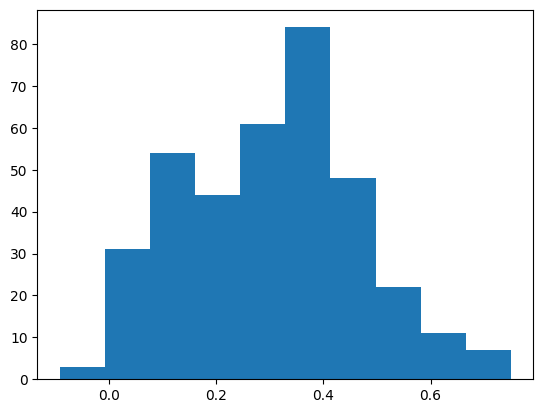

In [15]:
import matplotlib.pyplot as plt

plt.hist(similarities)